#                       STK-IN1050 Statistikk for informatikere, V26
###                                                        Obligatorisk innlevering 3 av 4

**Student:** Luka Simic

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

### Oppgave 1: Opinionsdynamikker på et nettverk

#### Oppsett

Vi har 𝑁 personer koblet sammen i et nettverk. Hver person har til enhver tid én av to mulige meninger:
0 eller 1.

Nettverket beskriver hvem som er naboer (hvem som kan påvirke hvem). Vi bruker en sirkel som
nettverksstruktur. Personene nummereres 0, 1, … , 𝑁 − 1, og person 𝑖 har naboene (𝑖 − 1) mod 𝑁 og
(𝑖 + 1) mod 𝑁. Det betyr at hver person har nøyaktig to naboer. 

Person 𝑖 hvor 𝑖 ∈ {1, 2, … , 𝑁 − 2} er nabo med personer (𝑖 − 1) og (𝑖 + 1), og personer 0 og 𝑁 − 1 er også naboer med hverandre i tillegg til at person 0 er nabo med person 1 og person 𝑁 − 1 er nabo med person 𝑁 − 2.

Vi skal modellere følgende dynamikk:

I hvert tidssteg:
- Velg én tilfeldig person 𝑖 ∈ {0, 1, … , 𝑁 − 1}.
- Velg deretter tilfeldig én av de to naboene til person 𝑖.
- Person 𝑖 kopierer (adopterer) naboens mening.

• Prosessen fortsetter til alle har samme mening (konsensus, dvs. alle 0 eller alle 1), eller til vi har
nådd maks antall tidssteg.

Bruk følgende parametre:

- Antall personer: 𝑁 ∈ {10, 25}
- Startandel for mening 1: $𝑓_1$ ∈ {0.3, 0.5, 0.7}
- Maks antall tidssteg: $T_m$$_a$$_x$ = 10000

#### Oppgaver:

a) Implementer modellen:

1) Implementer nettverksstrukturen;
2) Gi hver person en tilfeldig mening 0 eller 1, med sannsynlighet $𝑓_1$ for mening 1;
3) Simuler én realisering fra modellen:
    1) Start fra en intialtilstand;
    2) Utfør tidssteg inntil konsensus er oppnådd, eller maks antall tidssteg er nådd;
    3) Registrer sluttmeningen (0 eller 1) og antall tidssteg.

In [2]:
def konsensus(n, f1, tmax=10000):
    personer = {i : 1 if random.random() < f1 else 0 for i in range(n)}
    tidssteg = 0
    while True:
        person = random.choice(list(personer.keys()))
        nabo = (person + random.choice([1,-1])) % n
        personer[person] = personer[nabo]
        if len(set(personer.values())) == 1 or tidssteg >= tmax:
            break
        tidssteg += 1
        
        if tidssteg >= tmax:
            return list(set(personer.values()))[0], 0 # 0 for dem som ikke når konsensus innen tmax.
        
    return list(set(personer.values()))[0], tidssteg    

b) For hver kombinasjon av 𝑁 ∈ {10, 25} og $𝑓_1$ ∈ {0.3, 0.5, 0.7}, kjør $R$ = 200 simuleringer. Vi skal
nå estimere to størrelser:
1) Sannsynlighet 𝑝 for at mening 1 vinner konsensus:

    • Definer indikatorvariabel: $X_r$ = 1 (hvis konsensus i simulering 𝑟 er mening 1); $X_r$ = 0 (ellers).
    
    • Definer estimator for $p$: $$
\hat{p} = \frac{1}{R} \sum_{i=1}^{R} X_r
$$
    
    • Beregn et estimat for 𝑝 og bruk bootstrap til å beregne et 95% konfidensintervall for 𝑝.
 

In [3]:
N = [10, 25]
f1_liste = [0.3, 0.5, 0.7]

R = 200
bs = 1000
p_hat = list()
KIer = {10 : {}, 25 : {}}
for n in N:
    for f1 in f1_liste:
        meninger = list()
        for _ in range(R):
            mening, tid = konsensus(n, f1)
            meninger.append(mening)
        p_hat.append(meninger.count(1) / len(meninger)) # Estimator p_hat.
        data = np.array(meninger)
        means = list()
        for _ in range(bs):
            sample = np.random.choice(data, size=len(data), replace=True) # Trekking med tilbakelegging.
            means.append(np.mean(sample))
        # Henter opp persentiler - for KI 95%: nedre 2.5% og øvre 97.5%.     
        KIer[n][f1] = [round(np.percentile(means,2.5),3), round(np.percentile(means,97.5),3)]
        print(f"For {n} personer og f1 = {f1}, p_hat = {meninger.count(1) / len(meninger) : .3f};"
             f" 95% konfidensintervall: {KIer[n][f1]}.")


For 10 personer og f1 = 0.3, p_hat =  0.295; 95% konfidensintervall: [0.23, 0.355].
For 10 personer og f1 = 0.5, p_hat =  0.515; 95% konfidensintervall: [0.445, 0.585].
For 10 personer og f1 = 0.7, p_hat =  0.690; 95% konfidensintervall: [0.625, 0.75].
For 25 personer og f1 = 0.3, p_hat =  0.285; 95% konfidensintervall: [0.225, 0.35].
For 25 personer og f1 = 0.5, p_hat =  0.505; 95% konfidensintervall: [0.44, 0.575].
For 25 personer og f1 = 0.7, p_hat =  0.685; 95% konfidensintervall: [0.62, 0.75].


2) Forventet tid 𝑇 til konsensus:

    • La $T_r$ være tid til konsensus i simulering $r$ (ignorer de som ikke når konsensus før $T_m$$_a$$_x$)
    
    • Definer estimator for 𝑇: $$
\bar{T} = \frac{1}{R} \sum_{i=1}^{R} T_r
$$
        

In [4]:
R = 200
bs = 1000
T_bar = list()
KIer_T_bar = {10 : {}, 25 : {}}
for n in N:
    for f1 in f1_liste:
        tider = list()
        for _ in range(R):
            mening, tid = konsensus(n,f1)
            if tid != 0: # Ignorerer simuleringer som ikke når konsensus innen tmax.
                tider.append(tid)
        T_bar.append(sum(tider)/len(tider))
        data = np.array(tider)
        means = list()
        for _ in range(bs):
            sample = np.random.choice(data, size=len(data), replace=True)
            means.append(np.mean(sample))
        KIer_T_bar[n][f1] = [round(np.percentile(means,2.5),3), round(np.percentile(means,97.5),3)]
        print(f"For {n} personer of f1 = {f1}, T_hat = {sum(tider)/len(tider):.3f};"
             f" 95% konfidensintervall: {KIer_T_bar[n][f1]}.")

For 10 personer of f1 = 0.3, T_hat = 89.312; 95% konfidensintervall: [77.355, 101.806].
For 10 personer of f1 = 0.5, T_hat = 104.835; 95% konfidensintervall: [90.428, 119.607].
For 10 personer of f1 = 0.7, T_hat = 84.640; 95% konfidensintervall: [72.534, 97.871].
For 25 personer of f1 = 0.3, T_hat = 1472.255; 95% konfidensintervall: [1225.824, 1713.102].
For 25 personer of f1 = 0.5, T_hat = 1663.332; 95% konfidensintervall: [1451.698, 1871.887].
For 25 personer of f1 = 0.7, T_hat = 1166.910; 95% konfidensintervall: [1013.831, 1337.802].


 c) Påvirker startandelen 𝑓1 sannsynligheten for at mening 1 vinner? Plott estimatene $\hat{p}$ mot 𝑓1 for
fast N, med bootstrap-konfidensintervaller. Kommenter: Virker det som om $\hat{p}$  ≈ 𝑓1?

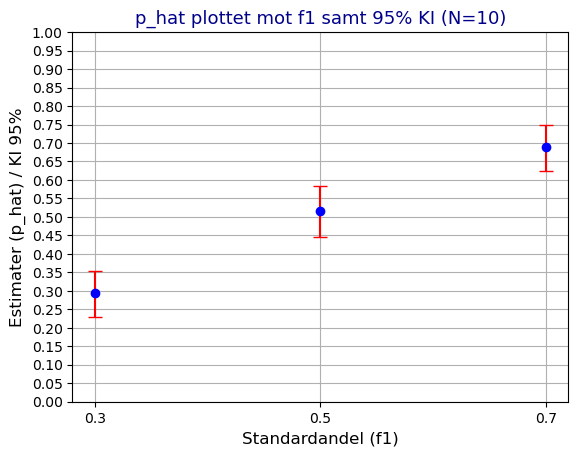

In [5]:
p_hat_10 = p_hat[0:3]
p_hat_25 = p_hat[3:]

# Filtrerer nedre og øvre konfidensintervaller etter p_hat.
nedre_10 = [abs(p_hat_10[p_hat_10.index(i)] - KIer[10][e][0]) for i,e in zip(p_hat_10, f1_liste)]
øvre_10 = [abs(KIer[10][e][1] - p_hat_10[p_hat_10.index(i)]) for e,i in zip(f1_liste, p_hat_10)]

# Plotter et errorbar-plott (viser estimater samt KI som vertikale linjer over/under punkter for estimater). 
plt.errorbar(x=f1_liste, y=p_hat_10, yerr=[nedre_10, øvre_10], fmt='o', color='blue', ecolor='red', capsize=5)
plt.xticks([0.3, 0.5, 0.7])
plt.yticks(np.arange(0, 1.01, 0.05))
plt.xlabel("Standardandel (f1)", fontsize=12)
plt.ylabel("Estimater (p_hat) / KI 95%", fontsize=12)
plt.title("p_hat plottet mot f1 samt 95% KI (N=10)", fontsize=13, color='darkblue')
plt.grid(True)
plt.show()

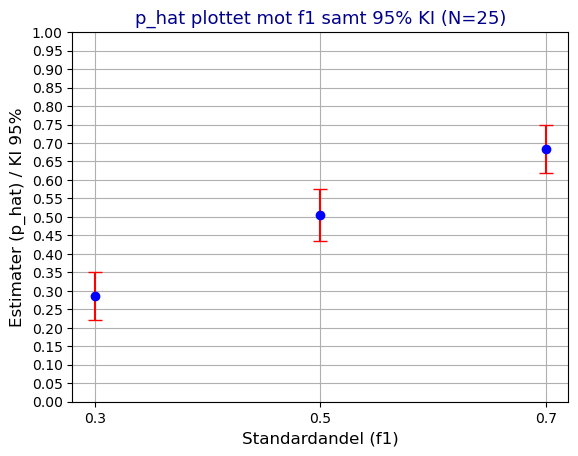

In [6]:
nedre_25 = [abs(p_hat_25[p_hat_25.index(i)] - KIer[25][e][1]) for i,e in zip(p_hat_25,f1_liste)]
øvre_25 = [abs(KIer[25][e][1] - p_hat_25[p_hat_25.index(i)]) for e,i in zip(f1_liste,p_hat_25)]

plt.errorbar(x=f1_liste, y=p_hat_25, yerr=[nedre_25, øvre_25], fmt='o', color='blue', ecolor='red', capsize=5)
plt.xticks([0.3, 0.5, 0.7])
plt.yticks(np.arange(0, 1.01, 0.05))
plt.xlabel("Standardandel (f1)", fontsize=12)
plt.ylabel("Estimater (p_hat) / KI 95%", fontsize=12)
plt.title("p_hat plottet mot f1 samt 95% KI (N=25)", fontsize=13, color='darkblue')
plt.grid(True)
plt.show()

**Kommentar:** Det virker som om $\hat{p}$ er ofte veldig nærme den standarde andelen. Det ser ut til at $\hat{p}$ er noe nærmere $f_1$ for mindre antallet mennesker, men det kommer mest sannsynlig bare fra variasjoner i forskjellige simuleringer. Variasjonen (KI intrevallet) er noe bredere for $f_1$= 0.5 hvor systemet er mer balansert og antall mennesker med meningen 0 og 1 er veldig nærme like i starten - det tar lengre tid å nå konsensus. 

d) Plott $\bar{T}$ (med konfidensintervall) som funksjon av $𝑓_1$. Blir tiden til konsensus typisk lengre eller
kortere når vi starter med $𝑓_1$ nær 0.5 enn når $𝑓_1$ er veldig lav eller veldig høy? Kommenter
eventuelle trender.

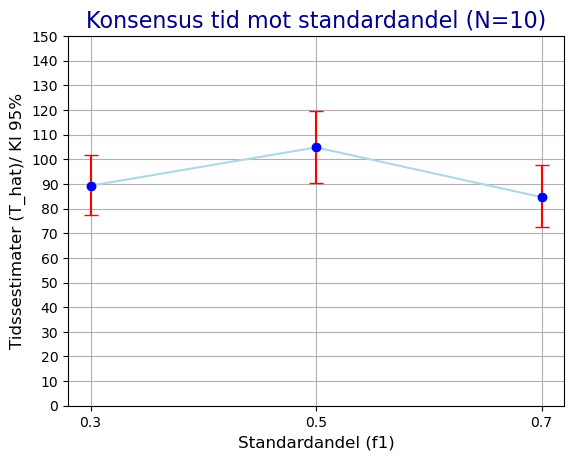

In [15]:
T_bar_10 = T_bar[0:3]
T_bar_25 = T_bar[3:]

nedre_10 = [abs(T_bar_10[T_bar_10.index(i)] - KIer_T_bar[10][e][0]) for i,e in zip(T_bar_10, f1_liste)]
øvre_10 = [abs(KIer_T_bar[10][e][1] - T_bar_10[T_bar_10.index(i)]) for e,i in zip(f1_liste, T_bar_10)]

plt.errorbar(x=f1_liste, y=T_bar_10, yerr=[nedre_10, øvre_10], fmt='o', capsize=5, color='blue', ecolor='red')
plt.plot(f1_liste, T_bar_10, '-o', color='lightblue')
plt.xticks([0.3, 0.5, 0.7])
plt.yticks(np.arange(0, 160, 10))
plt.xlabel("Standardandel (f1)", fontsize=12)
plt.ylabel("Tidssestimater (T_hat)/ KI 95%", fontsize=12)
plt.title("Konsensus tid mot standardandel (N=10)", fontsize=16, color='darkblue')
plt.grid(True)
plt.show()

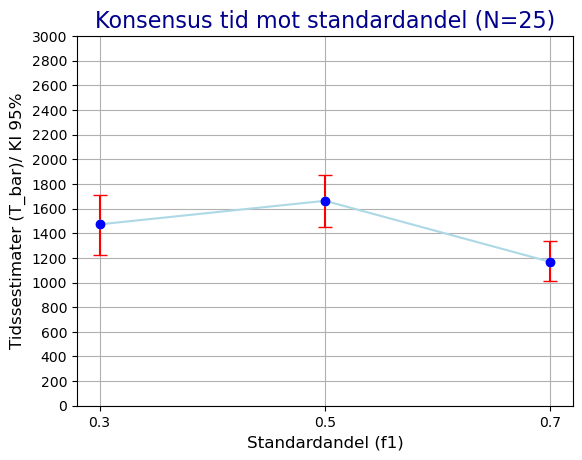

In [47]:
nedre_25 = [abs(T_bar_25[T_bar_25.index(i)] - KIer_T_bar[25][e][0]) for i,e in zip(T_bar_25, f1_liste)]
øvre_25 = [abs(KIer_T_bar[25][e][1] - T_bar_25[T_bar_25.index(i)]) for e,i in zip(f1_liste, T_bar_25)]

plt.errorbar(x=f1_liste, y=T_bar_25, yerr=[nedre_25, øvre_25], fmt='o', capsize=5, color='blue', ecolor='red')
plt.plot(f1_liste, T_bar_25, '-o', color='lightblue')
plt.xticks([0.3, 0.5, 0.7])
plt.yticks(np.arange(0, 3100, 200))
plt.xlabel("Standardandel (f1)", fontsize=12)
plt.ylabel("Tidssestimater (T_bar)/ KI 95%", fontsize=12)
plt.title("Konsensus tid mot standardandel (N=25)", fontsize=16, color='darkblue')
plt.grid(True)
plt.show()

**Kommentar:** Tiden blir typisk lengre når vi starter nær $f_1$ = 0.5, fordi systemet da er veldig nærme balansert, så det tar lengre tid å nå en konsensus, enn når $f_1$ er rundt 0.3 eller 0.7 (nærmere 0 og 1). Vi kan også se at KI er minste for mindre/større verdier av $f_1$ - konsensus oppnås raskest og med minst usikkerhet rundt det når balansen i starten er skyvet mot en side (enten 0 eller 1). 

e) Diskuter kort modellens begrensninger og mulige utvidelser.

**Svar:** Nettverksstrukturen er veldig enkel og selv om dynamikken i prosessen er tilfeldig, så er ikke selve nettverket tilfeldig. Hver person har bare to naboer og da får man veldig lite tilfeldighet i prosessen til overbevisning. Så systemet kunne være noe mer tilfeldig, systemet kunne la hver person ha mer enn bare 2 
naboer (mye nærmere virkelighet), men også kunne systemet ha forskjellige overbevisningspotensialer til forskjellige personer (som er ganske slikt det er i virkeligheten). Dette gjør systemet til å være mye mer komplisert, men også mye næremer til hvordan ting er i virkelighet. 

### Oppgave 2: Simulering av skogbrann på rutenett

#### Oppsett

Vi skal simulere en stokastisk modell for skogbrann på et kvadratisk rutenett av størrelse L × L. Hver
celle i rutenettet representerer et tre, og kan være én av tre tilstander:

   - 0: usvidd tre
   - 1: brennende tre
   - 2: brent tre
   
Vi bruker en struktur med 4 naboer: til en celle (i, j) hører naboene (i − 1, j), (i + 1, j), (i, j − 1),
(i, j + 1), hvis disse ligger innenfor rutenettet. Hvis noen av disse cellene ligger utenfor rutenettet, så
har cellen færre en 4 naboer.

Bruk følgende parametre:

   • Rutenettstørrelse L = 50
    
   • Sannsynlighet for at ild sprer seg fra et brennende tre til et usvidd nabotre i ett tidssteg,
     q ∈ {0.2, 0.3, 0.4, 0.5, 0.6, 0.7}
     
Initialtilstand (tid t = 0):

   • Alle celler settes til 0 (usvidde trær).
   
   • Alle trær i venstre kolonne (kolonne 0) tennes: disse cellene settes til 1 (brenner).
   
Dynamikk (ett tidssteg): Gitt tilstanden ved tid t, lager vi en ny rutenett-tilstand for tid t + 1:

1. For hver celle (i, j):

    a. Hvis cellen brenner (har tilstand 1) ved tid t:
    
      • For hver av de (opptil) 4 naboene: Hvis naboen er usvidd (har tilstand 0) ved tid t, tar
        den fyr ved tid t + 1 med sannsynlighet t.
        
      • Cellen selv blir brent ved tid t + 1 (får tilstand 2).
      
2. Tiden økes med 1.

Simuleringen stopper når det ikke finnes noen brennende celler (ingen 1-ere).

Definisjoner:

   • La 𝑌 = 1 hvis brannen på et eller annet tidspunkt har tent minst ett tre i høyre kolonne (kolonne
     L − 1), ellers Y = 0.
     
   • La 𝐹 være andelen brente trær når simuleringen er ferdig:$$
F = \frac{B}{L^2}
$$

   der B er antall celler i tilstand 2.

#### Oppgaver

a) Implementer modellen:

   1) Implementer rutenettet (som liste av lister eller numpy-array) og en funksjon som initialiserer
      tilstanden ved tid 0 for gitt L.
      
       
   2) Implementer en funksjon som utfører ett tidssteg i modellen for gitt rutenett og parameter q.
   

   3) Lag en funksjon som kjører én full simulering fra start til slutt, og returnerer:
   
       • om brannen har nådd høyre kant eller ikke (verdien til Y)
       
       • hvor stor andel av trærne som til slutt er brent (verdien til F)

In [30]:
def initialiser(L):
    rn = np.zeros((L,L))
    for i in range(len(rn)): # Oppretter 0-tilstanden.
        rn[i][0] = 1
    return rn

def tidssteg(rn, q):
    rn_next = rn.copy() # Vi ønsker ikke å endre det opprinnelige rutenettet.
    for i in range(len(rn)):
        for j in range(len(rn[i])):
            if rn[i][j] == 1: # Sjekker om et tre 'brenner'.
                nm = [(1,0), (-1,0), (0,1), (0,-1)] # Oppretter naboer.
                for x in nm:
                    ni = i + x[0]
                    nj = j + x[1]
                    # Sjekker om naboen passer rutenettet.
                    if ni >= 0 and ni < len(rn) and nj >= 0 and nj < len(rn[ni]):
                        # Hvis naboen passer, sjekker om den blir 'brennende'.
                        if rn[ni][nj] == 0 and np.random.rand() < q: 
                            rn_next[ni][nj] = 1
                rn_next[i][j] = 2 # Et 'brennende' tre blir brent.
    return rn_next

def simulering(rn, q):
    rn_sim = rn.copy()
    while (np.any(rn_sim == 1)): # Slutten til simuleringer - trær er enten brente eller usvidd i rutenettet.
        rn_sim = tidssteg(rn_sim, q)
    Y = int(np.any(rn_sim[:,-1] == 2))
    F = np.sum(rn_sim == 2) / rn_sim.size
    return Y, F

b) Monte Carlo–simuleringer: Vi skal undersøke hvordan brannens oppførsel avhenger av $q$. For hver
verdi av $q$:

   1) Utfør $R$ = 200 uavhengige simuleringer, og lagre utfallet $Y_r$ og $F_r$ for hvert simulering $r$.
   
   2) Estimer sannsynligheten p for at brannen når høyre kant ved å bruke estimatet: $$
\hat{p} = \frac{1}{R} \sum_{i=1}^{R} Y_r
$$

   og andelen brente trær 𝐹 ved gjennomsnittlig simulert andel brente trær: $$
\bar{F} = \frac{1}{R} \sum_{i=1}^{R} F_r
$$

c) Bootstrap og konfidensintervaller: For hver verdi av 𝑞:

   1) Bruk bootstrap til å konstruere et 95 % konfidensintervall for 𝑝, basert på de 𝑅 observasjonene
      $𝑌_1$, … , $𝑌_𝑅$.
   <br>
   2) Bruk bootstrap til å konstruere et 95 % konfidensintervall for 𝐹, basert på de 𝑅 observasjonene
      $𝐹_1$, … , $𝐹_𝑅$.

In [33]:
R = 200
bs = 1000
q_er = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
p_hat = list()
F_bar = list()

for q in q_er:
    rn = initialiser(50)
    # Kjører listeforståelse og bruker Numpy array for simuleringer.
    liste = np.array([simulering(rn,q) for _ in range(R)])
    p_hat.append(round(float(np.mean(liste[:,0])),3))
    F_bar.append(round(float(np.mean(liste[:,1])),3))

# Her har jeg valgt å kjøre boostrap for både p_hat og F_bar.
KIer_p_hat = dict()
KIer_F_bar = dict()

for q in q_er:
    rn = initialiser(50)
    y_liste = list()
    f_liste = list()
    y_means = list()
    f_means = list()
    for _ in range(R):
        y, f = simulering(rn,q)
        y_liste.append(y)
        f_liste.append(f)
    data_y = np.array(y_liste)
    data_f = np.array(f_liste)
    for _ in range(bs):
        sample_y = np.random.choice(data_y, size=len(data_y), replace=True)
        sample_f = np.random.choice(data_f, size=len(data_f), replace=True)
        y_means.append(np.mean(sample_y))
        f_means.append(np.mean(sample_f))
    KIer_p_hat[q] = [round(float(np.percentile(y_means,2.5)),3),round(float(np.percentile(y_means,97.5)),3)]
    KIer_F_bar[q] = [round(float(np.percentile(f_means,2.5)),3),round(float(np.percentile(f_means,97.5)),3)]

for q, phat in zip(list(KIer_p_hat.keys()), p_hat):
    print(f"For q = {q}, p_hat = {phat}; 95% konfidensintervall: [{KIer_p_hat[q][0]}, {KIer_p_hat[q][1]}].")
print("\n")
for q, Fbar in zip(list(KIer_F_bar.keys()), F_bar):
    print(f"For q = {q}, F_bar = {Fbar}; 95% konfidensintervall: [{KIer_F_bar[q][0]}, {KIer_F_bar[q][1]}].")

For q = 0.2, p_hat = 0.0; 95% konfidensintervall: [0.0, 0.0].
For q = 0.3, p_hat = 0.0; 95% konfidensintervall: [0.0, 0.0].
For q = 0.4, p_hat = 0.0; 95% konfidensintervall: [0.0, 0.0].
For q = 0.5, p_hat = 0.47; 95% konfidensintervall: [0.415, 0.545].
For q = 0.6, p_hat = 1.0; 95% konfidensintervall: [1.0, 1.0].
For q = 0.7, p_hat = 1.0; 95% konfidensintervall: [1.0, 1.0].


For q = 0.2, F_bar = 0.028; 95% konfidensintervall: [0.027, 0.028].
For q = 0.3, F_bar = 0.039; 95% konfidensintervall: [0.038, 0.039].
For q = 0.4, F_bar = 0.074; 95% konfidensintervall: [0.071, 0.077].
For q = 0.5, F_bar = 0.452; 95% konfidensintervall: [0.429, 0.483].
For q = 0.6, F_bar = 0.934; 95% konfidensintervall: [0.932, 0.936].
For q = 0.7, F_bar = 0.986; 95% konfidensintervall: [0.985, 0.986].


d) Analyse og diskusjon: Bruk resultatene til å svare på følgende:

   1) Plott $\hat{p}$ som funksjon av 𝑞, med 95 % konfidensintervaller (for eksempel som vertikale
      feilstolper). Beskriv hvordan sannsynligheten for at brannen når høyre kant endrer seg når 𝑞
      øker. Finn et (omtrentlig) intervall av 𝑞-verdier hvor overgangen går fra “nesten aldri” til
      “nesten alltid".                                                                              
      <br>
   2) Plott $\bar{F}$ som funksjon av 𝑞, med 95 % konfidensintervaller. Diskuter hvordan den gjennom-
      snittlige andelen brente trær øker med 𝑞. Er det stor variasjon (stor usikkerhet) for enkelte
      𝑞-verdier?
      <br>
      
   3) Diskuter kort modellens begrensninger og eventuelle utvidelser.

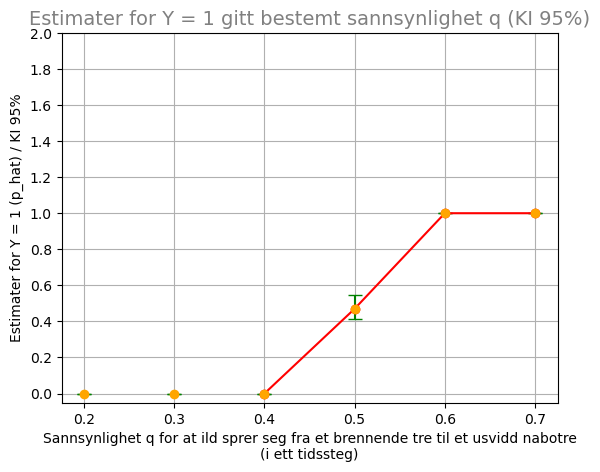

In [45]:
nedre_y = [abs(p_hat[p_hat.index(i)] - KIer_p_hat[q][0]) for i,q in zip(p_hat, list(KIer_p_hat.keys()))]
øvre_y = [abs(KIer_p_hat[q][1] - p_hat[p_hat.index(i)]) for q,i in zip(list(KIer_p_hat.keys()), p_hat)]

plt.errorbar(x=q_er, y=p_hat, yerr=[nedre_y, øvre_y], fmt='o', capsize=5, color='orange', ecolor='green')
# En rød linje som knytter endringen fra ingen tre i høyre kanten "neste aldri" brenner til trær i 
# høyre skogskanten "nesten alltid" brenner.
plt.plot(q_er[2:], p_hat[2:], '-o', color='red')
plt.yticks(np.arange(0,2.2,0.2))
plt.xlabel("Sannsynlighet q for at ild sprer seg fra et brennende tre til et usvidd nabotre\n(i ett tidssteg)", 
           fontsize=10)
plt.ylabel("Estimater for Y = 1 (p_hat) / KI 95%", fontsize=10)
plt.title("Estimater for Y = 1 gitt bestemt sannsynlighet q (KI 95%)", fontsize=14, color='gray')
plt.grid(True)
plt.show()

**Kommentar:** Ved veldig lave q verdier blir det umulig for brannen til å nå den høyre kanten av skogen. $q$-verdi intervallet hvor overgangen går fra "nesten aldri" til "nesten alltid" går fra litt over $q$ = 0.4 og fram til $q$ = 0.6 (lett synlig fra plottet). For $q$ = 0.5 har p_hat den største usikkerhet (KI 95% intervallet) blir 
lengst som vanlig. Dette skyldes den største usikkerheten om brannen når høyre kanten ved q = 0.5 (ved q verdier under 0.5 blir $Y$ = 0 nesten alltid og motsatt ved verdier over 0.5). For høye verdier av $q$ når brannen nesten alltid den høyre skogskanten. 

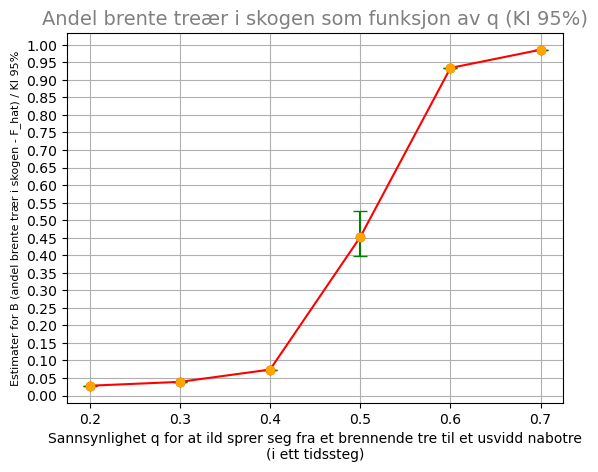

In [46]:
nedre_f = [abs(F_bar[F_bar.index(i)] - KIer_F_bar[q][0]) for i,q in zip(F_bar,list(KIer_F_bar.keys()))]
øvre_f = [abs(KIer_F_bar[q][1] - F_bar[F_bar.index(i)]) for q,i in zip(list(KIer_F_bar.keys()),F_bar)]

plt.errorbar(x=q_er, y=F_bar, yerr=[nedre_y, øvre_y], fmt='o', capsize=5, color='orange', ecolor='green')
plt.plot(q_er, F_bar, '-o', color='red')
plt.yticks(np.arange(0,1.05,0.05))
plt.xlabel("Sannsynlighet q for at ild sprer seg fra et brennende tre til et usvidd nabotre\n(i ett tidssteg)", 
           fontsize=10)
plt.ylabel("Estimater for B (andel brente trær i skogen - F_hat) / KI 95%", fontsize=8)
plt.title("Andel brente treær i skogen som funksjon av q (KI 95%)", fontsize=14, color='gray')
plt.grid(True)
plt.show()

**Kommentar:** Ved lave $q$ verdier blir det veldig liten andel brente trær i skogen ('brent': tilstand 2; ild overføres ikke så ofte til andre trær - 'brennende' trær endrer ikke tilstand til 2). Der kan vi også se ganske smale KI 95% intervaller siden den lave andelen varierer ikke så mye (det blir lite usikkerhet rundt at det ikke blir mange brente trær i skogen). Situasjonen begynner å endre seg ved $q$ = 0.5. Vi kan se bredere KI 95% intervallet rundt $q$ = 0.5 (størst variasjon av andelen brente trær - størst usikkerhet om et brennende tre overfører ilden til sin nabo; sammsvarer med at KI 95% intervallet for $\hat{p}$ også er største for $q$ = 0.5). KI 95% intervallen begynner å minske igjen for $q$ verdiene over 0.6 og blir veldig smale for høyere $q$ verdier, hvor vi kan se at $\bar{F}$ har høyeste verdier - nesten alle trær i skogen er brent og det blir veldig lite usikkerhet rundt det (siden - største sannsynlighet for at et brennende tre overfører ilden til sin nabotre og endre tilstanden sin til 'brent' (2)).

En mulig utvidelse/forbedring kan være å øke tilfeldigheten ved den initiale tilstanden i skogen. Her kan man velge å introdusere brann på en mer tilfeldig måte - tilfeldig antall trær som blir brennende ved tidssteget 0, men også tilfeldige posisjoner i rutenettet som blir brennende. Dette kan introdusere mer tilfeldighet, samt usikkerhet i modellen og muligens representerer bedre måten hvordan skosbrann starter og utvider seg i virkelighet. Eventuell utvidelse av modellen hadde også vært å tilfeldig velge sider av rutenettet hvor brann oppstår og i hvor stor grad (antall celler som brenner ved tidssteget 0). Vi kan tenke at brann kann oppstå på hvilken som helst av de 4 sidene til rutenettet og på mer enn en side om gangen. Modellen kunne også utvides med at hvert tre har flere tilstand det kan befinnes i (ikke hvert tre som brenne blir til slutt fullstendig brent - noen brennende trær kan også slukkes).  